# Influential outliers comparison with BART

The goal of this notebook is to compare our influential outlier metric with the work by Pratola et al. and their Cook's distiance for Bayesian regression trees. We find similar performance on a simple data set with obvious influential outliers.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestRegressor

c:\ProgramData\mambaforge\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
from main_iom import *

## BART influence metrics

We first read in the data and plot it.

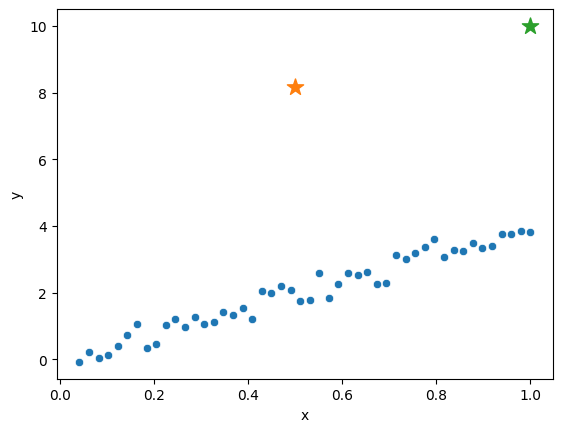

In [3]:
Data = pd.read_csv("Data_BART.csv").drop("Unnamed: 0", axis=1)
Data = Data.rename({"V1": 'x', "V2": "y"}, axis=1)
sns.scatterplot(Data, x='x', y='y')
plt.scatter(Data['x'][0], Data['y'][0], marker="*", s=150)
plt.scatter(Data['x'][1], Data['y'][1], marker="*", s=150) 


The BART model was fit using the `Ropenbt` package in `R`. The code for this can be found on Pratola's website https://bitbucket.org/mpratola/openbt/wiki/Home. We read in the regression curve by BART as well as the influence statistics from `R` and join them.

In [4]:
fitp = pd.read_csv("BART_fit.csv", sep="\t", header=None)
fitp = fitp[fitp[0]<=1]
fitp_wo = pd.read_csv("BART_fit_without_out.csv")
fitp_wo = fitp_wo[fitp_wo['x']<=1]
cook_d = pd.read_csv("BART_cd.csv", sep="\t")
Cook = pd.concat([Data, cook_d], axis=1)

We first plot the regression curve predicted by BART.

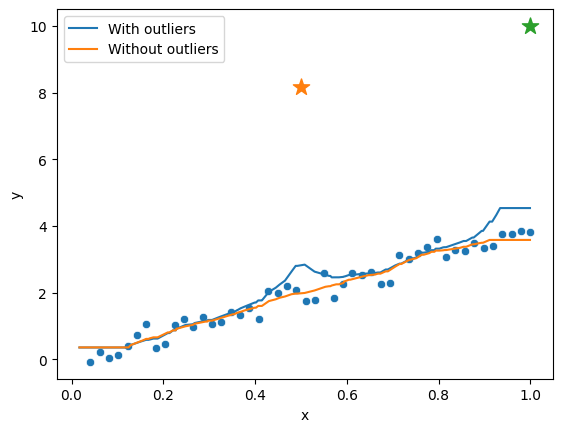

In [5]:
sns.scatterplot(Data, x='x', y='y')
sns.lineplot(fitp, x=0, y=1, label="With outliers")
sns.lineplot(fitp_wo, x='x', y='y', label="Without outliers")
plt.scatter(Data['x'][0], Data['y'][0], marker="*", s=150)
plt.scatter(Data['x'][1], Data['y'][1], marker="*", s=150)    

Now for the influence measurements, the $2\sigma$ and $3\sigma$ cutoff calculated as follows. 

In [6]:
ref_cookd_2sd = 1/8*2**2*10/9**2
ref_cookd_3sd = 1/8*3**2*10/9**2

And we plot them.

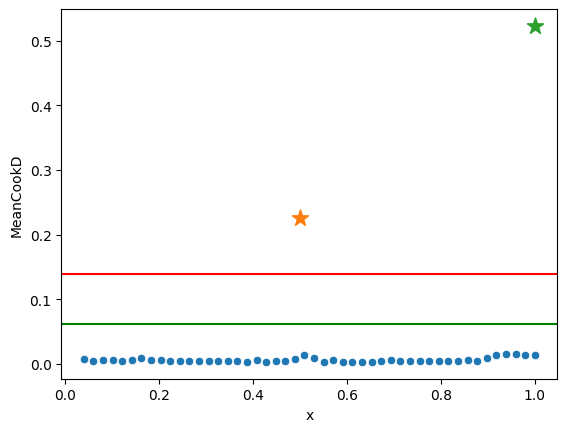

In [7]:
sns.scatterplot(Cook, x='x', y='MeanCookD')
plt.scatter(0.5, 0.226063, marker="*", s=150)  
plt.scatter(1,  0.522991, marker="*", s=150)  
plt.axhline(y=ref_cookd_2sd, color='green')
plt.axhline(y=ref_cookd_3sd, color='red')

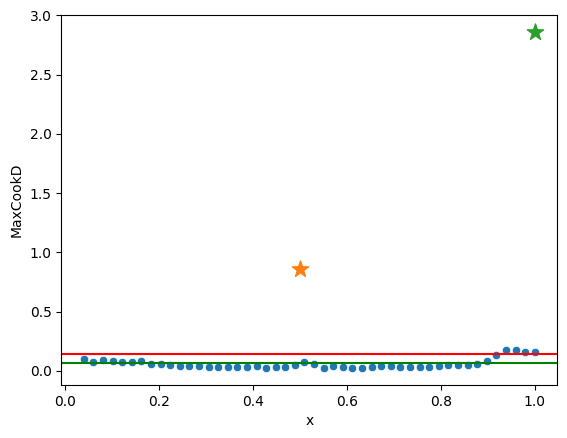

In [8]:
sns.scatterplot(Cook, x='x', y='MaxCookD')

plt.scatter(0.5, 0.857896, marker="*", s=150)  
plt.scatter(1,  2.860390, marker="*", s=150) 
plt.axhline(y=ref_cookd_2sd, color='green')
plt.axhline(y=ref_cookd_3sd, color='red')

## BART IOM

We test the IOM on BART using the `stochtree`. We trick `TreeExplainer` to take the BART model.

In [71]:
from collections import deque

In [4]:
from stochtree import BARTModel

bart = BARTModel()
bart.sample(X_train=Data[['x']], y_train=Data[['y']].values, num_gfr=10, num_mcmc=1000)


In [86]:
import numpy as np
import shap
from collections import deque

# =============================================================
# Extract one stochtree tree as a dict for SingleTree
# =============================================================
def _extract_one_tree(fc, sample_idx, tree_idx, X_train):
    old_ids = []
    queue = deque([0])
    visited = set()
    while queue:
        nid = queue.popleft()
        if nid in visited:
            continue
        visited.add(nid)
        old_ids.append(nid)
        if not fc.is_leaf_node(sample_idx, tree_idx, nid):
            queue.append(fc.left_child_node(sample_idx, tree_idx, nid))
            queue.append(fc.right_child_node(sample_idx, tree_idx, nid))
    
    old_to_new = {old: new for new, old in enumerate(old_ids)}
    n = len(old_ids)
    
    children_left = np.full(n, -1, dtype=np.int32)
    children_right = np.full(n, -1, dtype=np.int32)
    features = np.full(n, -2, dtype=np.int32)
    thresholds = np.full(n, -2.0, dtype=np.float64)
    values = np.zeros((n, 1), dtype=np.float64)
    
    for old_id in old_ids:
        new_id = old_to_new[old_id]
        if fc.is_leaf_node(sample_idx, tree_idx, old_id):
            lv = fc.node_leaf_values(sample_idx, tree_idx, old_id)
            values[new_id, 0] = lv[0]
        else:
            left_old = fc.left_child_node(sample_idx, tree_idx, old_id)
            right_old = fc.right_child_node(sample_idx, tree_idx, old_id)
            children_left[new_id] = old_to_new[left_old]
            children_right[new_id] = old_to_new[right_old]
            features[new_id] = fc.node_split_index(sample_idx, tree_idx, old_id)
            thresholds[new_id] = fc.node_split_threshold(sample_idx, tree_idx, old_id)
    
    node_sample_weight = np.zeros(n, dtype=np.float64)
    for i in range(X_train.shape[0]):
        node = 0
        while children_left[node] != -1:
            node_sample_weight[node] += 1.0
            if X_train[i, features[node]] <= thresholds[node]:
                node = children_left[node]
            else:
                node = children_right[node]
        node_sample_weight[node] += 1.0
    
    return {
        "children_left": children_left,
        "children_right": children_right,
        "children_default": children_left.copy(),
        "features": features,
        "thresholds": thresholds,
        "values": values,
        "node_sample_weight": node_sample_weight,
    }


def stochtree_to_shap(bart_model, X_train, sample_idx=-1):
    fc = bart_model.forest_container_mean
    if sample_idx < 0:
        sample_idx = fc.num_samples() + sample_idx
    
    n_trees = fc.num_trees
    
    tree_dicts = []
    for tree_idx in range(n_trees):
        td = _extract_one_tree(fc, sample_idx, tree_idx, X_train)
        tree_dicts.append(td)
    
    model_dict = {
        "trees": tree_dicts,
        "base_offset": 0.0,
        "tree_output": "raw_value",
        "objective": "squared_error",
        "input_dtype": np.float64,
        "internal_dtype": np.float64,
    }
    
    return model_dict


# =============================================================
# Predict by manually walking trees (for verification)
# =============================================================
def predict_from_trees(tree_dicts, X):
    """Predict by summing leaf values across all trees."""
    n_obs = X.shape[0]
    preds = np.zeros(n_obs)
    
    for td in tree_dicts:
        cl = td["children_left"]
        cr = td["children_right"]
        feat = td["features"]
        thresh = td["thresholds"]
        vals = td["values"]
        
        for i in range(n_obs):
            node = 0
            while cl[node] != -1:
                if X[i, feat[node]] <= thresh[node]:
                    node = cl[node]
                else:
                    node = cr[node]
            preds[i] += vals[node, 0]
    
    return preds


# =============================================================
# Run it
# =============================================================
X_train = Data[['x']].values

fc = bart.forest_container_mean
sample_idx = fc.num_samples() - 1

print("Converting stochtree → shap model dict...")
model_dict = stochtree_to_shap(bart, X_train, sample_idx)
print(f"  {len(model_dict['trees'])} trees")

print("Creating TreeExplainer...")
explainer = shap.TreeExplainer(model_dict)

print("Computing SHAP values...")
shap_values_bart = explainer.shap_values(X_train)
print(f"  Shape: {shap_values_bart.shape}")

# Verify using our own tree prediction
pred = predict_from_trees(model_dict["trees"], X_train)
baseline = pred.mean()

print("\nVerification: sum(SHAP) ≈ f(x) - E[f(x)]")
for i in range(10):
    target = pred[i] - baseline
    got = shap_values[i].sum()
    err = abs(target - got)
    print(f"  Obs {i}: target={target:+.8f}  "
          f"sum={got:+.8f}  err={err:.2e} "
          f"{'✓' if err < 1e-6 else '✗'}")

# Also verify predictions match stochtree's predict
bart_pred = bart.predict(X_train)['y_hat'].mean(axis=0)  # posterior mean
our_pred = pred  # single posterior draw
print(f"\nOur tree prediction range: [{our_pred.min():.4f}, {our_pred.max():.4f}]")
print(f"BART posterior mean range: [{bart_pred.min():.4f}, {bart_pred.max():.4f}]")

Converting stochtree → shap model dict...
  200 trees
Creating TreeExplainer...
Computing SHAP values...
  Shape: (50, 1)

Verification: sum(SHAP) ≈ f(x) - E[f(x)]
  Obs 0: target=-0.17791229  sum=-0.17791229  err=3.61e-16 ✓
  Obs 1: target=+1.12210751  sum=+1.12210751  err=0.00e+00 ✓
  Obs 2: target=-0.94932740  sum=-0.94932740  err=0.00e+00 ✓
  Obs 3: target=-0.94932740  sum=-0.94932740  err=0.00e+00 ✓
  Obs 4: target=-0.94932740  sum=-0.94932740  err=0.00e+00 ✓
  Obs 5: target=-0.94932740  sum=-0.94932740  err=0.00e+00 ✓
  Obs 6: target=-0.94932740  sum=-0.94932740  err=0.00e+00 ✓
  Obs 7: target=-0.97604492  sum=-0.97604492  err=0.00e+00 ✓
  Obs 8: target=-0.98988592  sum=-0.98988592  err=2.22e-16 ✓
  Obs 9: target=-0.87530260  sum=-0.87530260  err=2.22e-16 ✓

Our tree prediction range: [-0.9979, 1.1141]
BART posterior mean range: [1.7668, 3.0287]


In [87]:
resid_bart = Data['y'].values - bart.predict(Data[['x']].values)['y_hat'].mean()

In [88]:
print(f"SHAP values: {stats.shapiro(shap_values_bart.reshape(-1)).pvalue:.4f}")
print(f"Residuals: {stats.shapiro(resid_bart.reshape(-1)).pvalue:.4f}")

SHAP values: 0.0129
Residuals: 0.0000


In [90]:
iom_bart = InfluentialOutlierMetric(shap_values_bart.reshape(-1,1), resid_bart,
                                    1, 1, 1, 
                                    2, 1, 2,
                                    lambdas=np.concatenate([[0], np.exp(np.linspace(-1, 5, 50))]),
                                    lambdas_resid=np.concatenate([[0], np.exp(np.linspace(-1, 5, 50))]),
                                    epoch=500, epoch_resid=500)

In [91]:
# Tune for lambda
iom_bart.find_best_lambda(alpha=0.05)
iom_bart.find_best_lambda_resid(alpha=0.05)

# Compute thresholds
thresholds = iom_bart.find_threshold(alpha=[0.05, 0.01])

# Compute IOM
IOM_bart = iom_bart.IOM()

Finding λ for SHAP values
Shapiro p-value = 0.0129
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:03<00:00, 135.79it/s]


p=0.1024
---
λ=0.3679


Normalizing flow: 100%|██████████| 500/500 [00:03<00:00, 129.31it/s]


p=0.0596
---
λ=0.4158


Normalizing flow: 100%|██████████| 500/500 [00:04<00:00, 100.65it/s]


p=0.0556
---
λ=0.4700


Normalizing flow: 100%|██████████| 500/500 [00:05<00:00, 90.84it/s] 


p=0.0483
---
Selected λ=0.4158, p=0.0556
Done!
Finding λ for residuals
Shapiro p-value = 0.0000
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 48.48it/s]


p=0.9312
---
λ=0.3679


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 47.09it/s]


p=0.4539
---
λ=0.4158


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 56.35it/s]


p=0.3809
---
λ=0.4700


Normalizing flow: 100%|██████████| 500/500 [00:09<00:00, 50.07it/s]


p=0.3117
---
λ=0.5312


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.46it/s]


p=0.2527
---
λ=0.6004


Normalizing flow: 100%|██████████| 500/500 [00:09<00:00, 52.20it/s]


p=0.2003
---
λ=0.6786


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 40.21it/s]


p=0.1557
---
λ=0.7670


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 49.30it/s]


p=0.1169
---
λ=0.8669


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 56.90it/s]


p=0.0887
---
λ=0.9798


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 46.73it/s]


p=0.0601
---
λ=1.1074


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 46.82it/s]

p=0.0467
---
Selected λ=0.9798, p=0.0601
Done!
Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


In [92]:
iom_bart.summary()

               Parameter     Value
             Samples (n) 50.000000
            Features (p)  1.000000
       Flow depth (SHAP)  1.000000
     Hidden units (SHAP)  1.000000
           Layers (SHAP)  1.000000
  Flow depth (Residuals)  2.000000
Hidden units (Residuals)  2.000000
      Layers (Residuals)  1.000000
          Final λ (SHAP)  0.415800
            SHAP p-value  0.055609
     Final λ (Residuals)  0.979799
        Residual p-value  0.060054
      Threshold (α=0.05)  4.760901
      Threshold (α=0.01) 12.990353


,Parameter,Value
0,Samples (n),50.000000
1,Features (p),1.000000
2,Flow depth (SHAP),1.000000
3,Hidden units (SHAP),1.000000
4,Layers (SHAP),1.000000
5,Flow depth (Residuals),2.000000
6,Hidden units (Residuals),2.000000
7,Layers (Residuals),1.000000
8,Final λ (SHAP),0.415800
9,SHAP p-value,0.055609


In [93]:
Data['IOM'] = IOM_bart

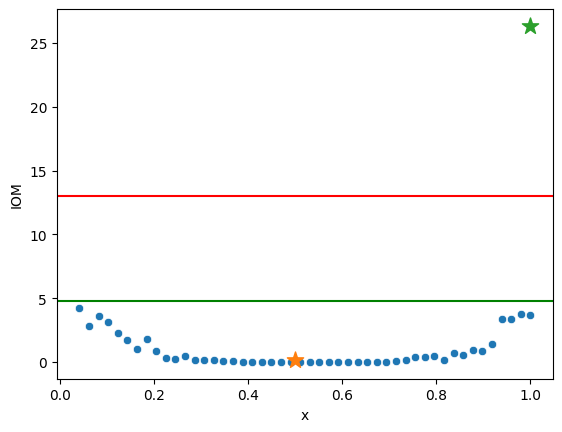

In [94]:
sns.scatterplot(Data, x='x', y='IOM')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
plt.scatter(0.5, Data.loc[0,'IOM'], marker="*", s=150)
plt.scatter(1, Data.loc[1, "IOM"], marker="*", s=150) 

## Random Forest and IOM

We fit a standard random forest from `scikit-learn`. 

In [17]:
clf = RandomForestRegressor(max_depth=2, random_state=0)
clf.fit(Data['x'].to_numpy().reshape(-1,1), Data['y'])

,n_estimators,100
,criterion,'squared_error'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


And we plot the estimated regression curve.

In [18]:
clf_2 = RandomForestRegressor(max_depth=2, random_state=0)
clf_2.fit(Data['x'].drop([0,1]).to_numpy().reshape(-1,1), Data['y'].drop([0,1]))

,n_estimators,100
,criterion,'squared_error'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
Pred = pd.concat([fitp[0], pd.Series(clf.predict(fitp[0].to_numpy().reshape(-1,1)))], axis=1, ignore_index=True)

In [20]:
Pred_2 = pd.concat([fitp[0].drop([0,1]), pd.Series(clf_2.predict(fitp[0].drop([0,1]).to_numpy().reshape(-1,1)))], axis=1, ignore_index=True)

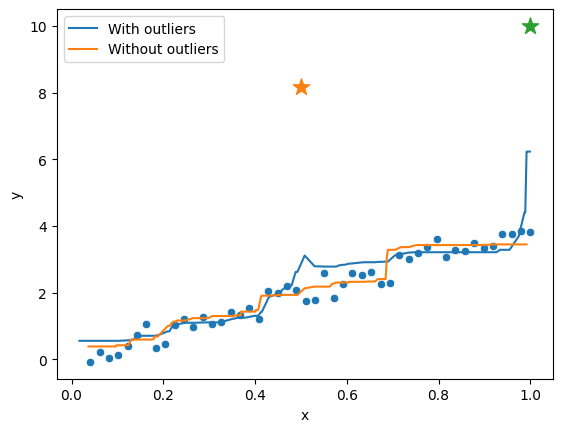

In [21]:
sns.scatterplot(Data, x="x", y="y")
sns.lineplot(Pred, x=0, y=1, label='With outliers')
sns.lineplot(Pred_2, x=0, y=1, label='Without outliers')
plt.scatter(0.5, 8.157989, marker="*", s=150)
plt.scatter(1, 9.996990, marker="*", s=150) 

We calculate the residuals.

In [22]:
resid = np.array(Data['y'] - clf.predict(Data['x'].to_numpy().reshape(-1,1)))

And using the `shap` package we calculate the SHAP values.

In [23]:
explainer_rf = shap.TreeExplainer(clf) 
shap_values_rf = explainer_rf.shap_values(Data['x'].to_numpy().reshape(-1,1)) 

We assess normality.

In [24]:
print(f"SHAP values: {stats.shapiro(shap_values_rf.reshape(-1)).pvalue:.4f}")
print(f"Residuals: {stats.shapiro(resid.reshape(-1)).pvalue:.4f}")

SHAP values: 0.0001
Residuals: 0.0000


In [25]:
iom_rf = InfluentialOutlierMetric(shap_values_rf.reshape(-1,1), resid,
                                    2, 2, 2, 
                                    2, 2, 2, 
                                    lambdas=np.concatenate([[0], np.exp(np.linspace(-3, 5, 50))]),
                                    lambdas_resid=np.concatenate([[0], np.exp(np.linspace(-4, 5, 50))]),
                                    epoch=500, epoch_resid=500)

In [26]:
# Tune for lambda
iom_rf.find_best_lambda(alpha=0.05)
iom_rf.find_best_lambda_resid(alpha=0.05)

# Compute thresholds
thresholds = iom_rf.find_threshold(alpha=[0.05, 0.01])

# Compute IOM
IOM_rf = iom_rf.IOM()

Finding λ for SHAP values
Shapiro p-value = 0.0001
λ=0.0000


Normalizing flow:   1%|          | 6/500 [00:00<00:19, 25.25it/s]

Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.00it/s]


p=0.1206
---
λ=0.0498


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.33it/s]


p=0.1318
---
λ=0.0586


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 32.99it/s]


p=0.1294
---
λ=0.0690


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.78it/s]


p=0.1277
---
λ=0.0813


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.68it/s]


p=0.1240
---
λ=0.0957


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.33it/s]


p=0.1218
---
λ=0.1126


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.35it/s]


p=0.1169
---
λ=0.1326


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.56it/s]


p=0.1153
---
λ=0.1561


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.34it/s]


p=0.1153
---
λ=0.1838


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.91it/s]


p=0.0997
---
λ=0.2164


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.93it/s]


p=0.0952
---
λ=0.2548


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.43it/s]


p=0.0851
---
λ=0.3000


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.52it/s]


p=0.0723
---
λ=0.3532


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 29.60it/s]


p=0.0620
---
λ=0.4158


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.02it/s]


p=0.0506
---
λ=0.4895


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.41it/s]


p=0.0397
---
Selected λ=0.4158, p=0.0506
Done!
Finding λ for residuals
Shapiro p-value = 0.0000
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:18<00:00, 27.51it/s]


p=0.7023
---
λ=0.0183


Normalizing flow: 100%|██████████| 500/500 [00:20<00:00, 24.57it/s]


p=0.5971
---
λ=0.0220


Normalizing flow: 100%|██████████| 500/500 [00:17<00:00, 29.37it/s]


p=0.5849
---
λ=0.0264


Normalizing flow: 100%|██████████| 500/500 [00:19<00:00, 25.71it/s]


p=0.5829
---
λ=0.0318


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.34it/s]


p=0.5795
---
λ=0.0382


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.53it/s]


p=0.5685
---
λ=0.0459


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 33.19it/s]


p=0.5687
---
λ=0.0551


Normalizing flow: 100%|██████████| 500/500 [00:18<00:00, 26.85it/s]


p=0.5695
---
λ=0.0663


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.36it/s]


p=0.4918
---
λ=0.0796


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 32.73it/s]


p=0.3308
---
λ=0.0957


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.04it/s]


p=0.3065
---
λ=0.1149


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.91it/s]


p=0.2173
---
λ=0.1381


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 32.81it/s]


p=0.1743
---
λ=0.1660


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 33.23it/s]


p=0.1381
---
λ=0.1994


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.44it/s]


p=0.1016
---
λ=0.2397


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.90it/s]


p=0.0683
---
λ=0.2880


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.92it/s]

p=0.0404
---
Selected λ=0.2397, p=0.0683
Done!
Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


In [27]:
iom_rf.summary()

               Parameter     Value
             Samples (n) 50.000000
            Features (p)  1.000000
       Flow depth (SHAP)  2.000000
     Hidden units (SHAP)  2.000000
           Layers (SHAP)  2.000000
  Flow depth (Residuals)  2.000000
Hidden units (Residuals)  2.000000
      Layers (Residuals)  2.000000
          Final λ (SHAP)  0.415800
            Shap p-value  0.050636
     Final λ (Residuals)  0.239651
        Residual p-value  0.068270
      Threshold (α=0.05)  4.760901
      Threshold (α=0.01) 12.990353


,Parameter,Value
0,Samples (n),50.000000
1,Features (p),1.000000
2,Flow depth (SHAP),2.000000
3,Hidden units (SHAP),2.000000
4,Layers (SHAP),2.000000
5,Flow depth (Residuals),2.000000
6,Hidden units (Residuals),2.000000
7,Layers (Residuals),2.000000
8,Final λ (SHAP),0.415800
9,Shap p-value,0.050636


In [28]:
Data['IOM'] = IOM_rf

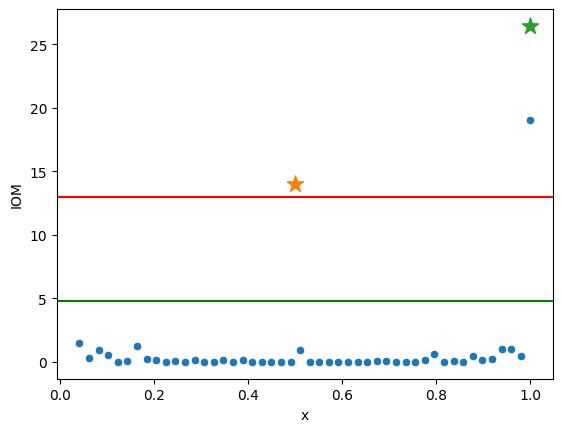

In [29]:
sns.scatterplot(Data, x='x', y='IOM')
plt.axhline(y=4.7609, color='green')
plt.axhline(y=12.9904, color='red')
plt.scatter(0.5, Data.loc[0,'IOM'], marker="*", s=150)
plt.scatter(1, Data.loc[1,'IOM'], marker="*", s=150) 